•	first baseline model (no holidays no ponts de mai no seasonality no regressor)

In [1]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

df = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine.xlsx")
df_data = df[df['domaine'] == 'Data/Cloud'][
    ['ds', 'y']
].sort_values('ds')
df_cyber = df[df['domaine'] == 'Cybersécurité'][
    ['ds', 'y']
].sort_values('ds')
df_devops = df[df['domaine'] == 'DevOps / Infra'][
    ['ds', 'y']
].sort_values('ds')
df_dev = df[df['domaine'] == 'Dev Fullstack'][
    ['ds', 'y']
].sort_values('ds')

df_agile = df[df['domaine'] == 'Agile & Delivery'][
    ['ds', 'y']
].sort_values('ds')


•	Function prophet baseline

In [4]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def train_evaluate_prophet(df, periods=12):
    # Séparation train/test
    train_df = df.iloc[:-periods]
    test_df = df.iloc[-periods:]
    
    # Modèle Prophet
    model = Prophet()
    model.fit(train_df)
    
    # Prévision
    future = model.make_future_dataframe(periods=periods, freq='W-MON')
    forecast = model.predict(future)
    
    # Récupérer les valeurs prédites pour la période de test
    y_pred = forecast['yhat'].iloc[-periods:].values
    y_true = test_df['y'].values
    
    # Calcul MAE et MAPE
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    print(f"MAE : {mae}")
    print(f"MAPE : {mape}\n")
    
    return mae, mape


In [ ]:
•	resultat pour chaque domaine

In [5]:
# Assurez-vous que chaque DataFrame a la colonne 'domaine' avec la valeur correspondante
print("domaine Data/cloud")
mae_data, mape_data = train_evaluate_prophet(df_data)

print("domaine cybersécurité")
mae_cyber, mape_cyber = train_evaluate_prophet(df_cyber)

print("domaine devops")
mae_devops, mape_devops = train_evaluate_prophet(df_devops)

print("domaine dev fullstack")
mae_dev, mape_dev = train_evaluate_prophet(df_dev)

print("domaine Agile")
mae_agile, mape_agile = train_evaluate_prophet(df_agile)


01:08:38 - cmdstanpy - INFO - Chain [1] start processing


domaine Data/cloud


01:08:38 - cmdstanpy - INFO - Chain [1] done processing
01:08:39 - cmdstanpy - INFO - Chain [1] start processing


MAE : 6.917931165096067
MAPE : 33.25908176094596

domaine cybersécurité


01:08:39 - cmdstanpy - INFO - Chain [1] done processing
01:08:39 - cmdstanpy - INFO - Chain [1] start processing


...

MAE : 3.5406178829300075
MAPE : 30.77203093008423

domaine dev fullstack


01:08:40 - cmdstanpy - INFO - Chain [1] done processing
01:08:40 - cmdstanpy - INFO - Chain [1] start processing


MAE : 3.5681784072953593
MAPE : 43.55290112856997

domaine Agile


01:08:40 - cmdstanpy - INFO - Chain [1] done processing


MAE : 3.47374495403135
MAPE : 34.252679286541984



•	cross validation sur baseline model Data/cloud

In [6]:
from prophet.diagnostics import cross_validation, performance_metrics
print("⏳ Cross-Validation du modèle BASELINE en cours...")
m_baseline = Prophet()
m_baseline.fit(df_data)

# Validation croisée :
# - initial='365 days' : au moins 1 an d'historique pour commencer l'entraînement
# - period='60 days'  : décale la fenêtre d'évaluation tous les 2 mois
# - horizon='84 days' : évalue sur un horizon de 12 semaines
df_cv_baseline = cross_validation(
    m_baseline, initial='365 days', period='60 days', horizon='84 days'
)
df_p_baseline = performance_metrics(df_cv_baseline)

mae_base = df_p_baseline['mae'].mean()
mape_base = df_p_baseline['mape'].mean() * 100


⏳ Cross-Validation du modèle BASELINE en cours...


01:08:59 - cmdstanpy - INFO - Chain [1] start processing
01:09:00 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/7 [00:00<?, ?it/s]

01:09:00 - cmdstanpy - INFO - Chain [1] start processing
01:09:01 - cmdstanpy - INFO - Chain [1] done processing
01:09:01 - cmdstanpy - INFO - Chain [1] start processing
01:09:02 - cmdstanpy - INFO - Chain [1] done processing
01:09:02 - cmdstanpy - INFO - Chain [1] start processing
01:09:03 - cmdstanpy - INFO - Chain [1] done processing
01:09:04 - cmdstanpy - INFO - Chain [1] start processing
01:09:05 - cmdstanpy - INFO - Chain [1] done processing
01:09:05 - cmdstanpy - INFO - Chain [1] start processing
01:09:06 - cmdstanpy - INFO - Chain [1] done processing
01:09:06 - cmdstanpy - INFO - Chain [1] start processing
01:09:08 - cmdstanpy - INFO - Chain [1] done processing
01:09:08 - cmdstanpy - INFO - Chain [1] start processing
01:09:08 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
print(mae_base)
print(mape_base)

16.692883975904426
71.02147193751127


•	intégration des jours fériés et des périodes de fermeture (composant holidays).

In [10]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np
def train_evaluate_prophet_with_holidays(df, holidays_df, periods=12):
    # Séparation train/test
    train_df = df.iloc[:-periods]
    test_df = df.iloc[-periods:]
    
    # Créer le modèle avec holidays
    model = Prophet(holidays=holidays_df,
            weekly_seasonality=False,  # Désactivé (données déjà hebdo)
            daily_seasonality=False,  # Désactivé
            yearly_seasonality=True,)
    model.add_seasonality(name='yearly', period=365.25, fourier_order=12)
    model.fit(train_df)
    
    # Prévision
    future = model.make_future_dataframe(periods=periods, freq='W-MON')
    forecast = model.predict(future)
    
    # Récupérer les valeurs prédites pour la période de test
    y_pred = forecast['yhat'].iloc[-periods:].values
    y_true = test_df['y'].values
    
    # Calcul MAE et MAPE
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
    wape_percentage = wape * 100
    
    print(f"MAE : {mae}")
    print(f"MAPE : {mape}\n")
    print(f"WAPE : {wape_percentage:.2f}%")

    
    return mae, mape, wape_percentage


In [17]:
import pandas as pd

holidays_df = pd.DataFrame({
    'holiday': [
        # --- 2023 ---
        'fete_du_travail',  # Lundi 1er Mai
        'victoire_1945',  # Lundi 8 Mai
        'ascension',  # Jeudi 18 Mai (Pont de 4 jours)
        'fete_nationale',  # Vendredi 14 Juillet (Week-end prolongé)
        'vacances_ete',  # Quinzaine d'août (1er au 15 août)
        'assomption',  # Mardi 15 Août (Pont le lundi 14)
        'noel',  # Lundi 25 Décembre (Semaine de fêtes)
        # --- 2024 ---
        'fete_du_travail',  # Mercredi 1er Mai
        'victoire_1945',  # Mercredi 8 Mai (Enchaîné avec l'Ascension)
        'ascension',  # Jeudi 9 Mai (Super pont de Mai)
        'fete_nationale',  # Dimanche 14 Juillet
        'vacances_ete',  # Quinzaine d'août (1er au 15 août)
        'assomption',  # Jeudi 15 Août (Pont le vendredi 16)
        'noel',  # Mercredi 25 Décembre (Semaine de fêtes)
        # --- 2025 ---
        'fete_du_travail',  # Jeudi 1er Mai (Pont le vendredi 2)
        'victoire_1945',  # Jeudi 8 Mai (Pont le vendredi 9)
        'ascension',  # Jeudi 29 Mai (Pont de 4 jours)
        'fete_nationale',  # Lundi 14 Juillet (Week-end prolongé)
        'vacances_ete',  # Quinzaine d'août (1er au 15 août)
        'assomption',  # Vendredi 15 Août (Week-end prolongé)
        'noel',  # Jeudi 25 Décembre (Semaine de fêtes)
    ],
    'ds': pd.to_datetime([
        # 2023
        '2023-05-01',
        '2023-05-08',
        '2023-05-18',
        '2023-07-14',
        '2023-08-01',
        '2023-08-15',
        '2023-12-25',
        # 2024
        '2024-05-01',
        '2024-05-08',
        '2024-05-09',
        '2024-07-14',
        '2024-08-01',
        '2024-08-15',
        '2024-12-25',
        # 2025
        '2025-05-01',
        '2025-05-08',
        '2025-05-29',
        '2025-07-14',
        '2025-08-01',
        '2025-08-15',
        '2025-12-25',
    ]),
    # lower_window : nombre de jours d'impact AVANT la date
    'lower_window': [
        # 2023
        0,
        0,
        0,
        0,
        0,
        -1,
        0,
        # 2024
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        # 2025
        0,
        0,
        0,
        0,
        0,
        0,
        0,
    ],
    # upper_window : nombre de jours d'impact APRÈS la date
    'upper_window': [
        # 2023
        0,
        0,
        3,
        2,
        14,  # Impact du 1er au 15 août (15 jours)
        0,
        6,
        # 2024
        0,
        0,
        3,
        0,
        14,  # Impact du 1er au 15 août (15 jours)
        1,
        6,
        # 2025
        1,
        1,
        3,
        2,
        14,  # Impact du 1er au 15 août (15 jours)
        2,
        7,
    ],
})
print("Data/cloud")
mae_data, mape_data, wape_data = train_evaluate_prophet_with_holidays(df_data, holidays_df)
print("cybersécurity")
mae_cyber, mape_cyber, wape_cyber = train_evaluate_prophet_with_holidays(df_cyber, holidays_df)
print("devops")
mae_devops, mape_devops, wape_devops = train_evaluate_prophet_with_holidays(df_devops, holidays_df)
print("dev fullstack")
mae_dev, mape_dev, wape_dev = train_evaluate_prophet_with_holidays(df_dev, holidays_df)
print("agile")
mae_agile, mape_agile, wape_agile = train_evaluate_prophet_with_holidays(df_agile, holidays_df)

01:24:36 - cmdstanpy - INFO - Chain [1] start processing


Data/cloud


01:24:36 - cmdstanpy - INFO - Chain [1] done processing
01:24:37 - cmdstanpy - INFO - Chain [1] start processing
01:24:37 - cmdstanpy - INFO - Chain [1] done processing


MAE : 6.617257510305822
MAPE : 33.87888903979011

WAPE : 27.96%
cybersécurity


01:24:37 - cmdstanpy - INFO - Chain [1] start processing
01:24:37 - cmdstanpy - INFO - Chain [1] done processing


MAE : 1.9000805322968894
MAPE : 27.108215830599296

WAPE : 19.49%
devops


01:24:37 - cmdstanpy - INFO - Chain [1] start processing


MAE : 3.5142210896024757
MAPE : 30.431611598300435

WAPE : 28.49%
dev fullstack


01:24:37 - cmdstanpy - INFO - Chain [1] done processing
01:24:38 - cmdstanpy - INFO - Chain [1] start processing
01:24:38 - cmdstanpy - INFO - Chain [1] done processing


MAE : 3.405279693687971
MAPE : 39.32253266194445

WAPE : 35.23%
agile
MAE : 5.6098685044835825
MAPE : 52.911121790127304

WAPE : 46.11%


•	Cross val avec holidays

In [12]:
from prophet.diagnostics import cross_validation, performance_metrics
print("⏳ Cross-Validation du modèle with holidays en cours...")
 #Créer le modèle avec holidays
model = Prophet(holidays=holidays_df,
            weekly_seasonality=False,  # Désactivé (données déjà hebdo)
            daily_seasonality=False,  # Désactivé
            yearly_seasonality=True,)
model.add_seasonality(name='yearly', period=365.25, fourier_order=12)
model.fit(df_data)

# Validation croisée :
# - initial='365 days' : au moins 1 an d'historique pour commencer l'entraînement
# - period='60 days'  : décale la fenêtre d'évaluation tous les 2 mois
# - horizon='84 days' : évalue sur un horizon de 12 semaines
df_cv_baseline = cross_validation(
    model, initial='365 days', period='60 days', horizon='84 days'
)
df_p_baseline = performance_metrics(df_cv_baseline)

mae_holidays = df_p_baseline['mae'].mean()
mape_holidays = df_p_baseline['mape'].mean() * 100
print(mae_holidays)
print(mape_holidays)


01:13:01 - cmdstanpy - INFO - Chain [1] start processing


⏳ Cross-Validation du modèle with holidays en cours...


01:13:01 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/7 [00:00<?, ?it/s]

01:13:01 - cmdstanpy - INFO - Chain [1] start processing
01:13:02 - cmdstanpy - INFO - Chain [1] done processing
01:13:02 - cmdstanpy - INFO - Chain [1] start processing
01:13:03 - cmdstanpy - INFO - Chain [1] done processing
01:13:03 - cmdstanpy - INFO - Chain [1] start processing
01:13:04 - cmdstanpy - INFO - Chain [1] done processing
01:13:04 - cmdstanpy - INFO - Chain [1] start processing
01:13:06 - cmdstanpy - INFO - Chain [1] done processing
01:13:07 - cmdstanpy - INFO - Chain [1] start processing
01:13:08 - cmdstanpy - INFO - Chain [1] done processing
01:13:08 - cmdstanpy - INFO - Chain [1] start processing
01:13:09 - cmdstanpy - INFO - Chain [1] done processing
01:13:09 - cmdstanpy - INFO - Chain [1] start processing
01:13:10 - cmdstanpy - INFO - Chain [1] done processing


16.000313666764622
68.92814618485428


•	Analyse de la décomposition du modèle (Tendance vs Saisonnalité).

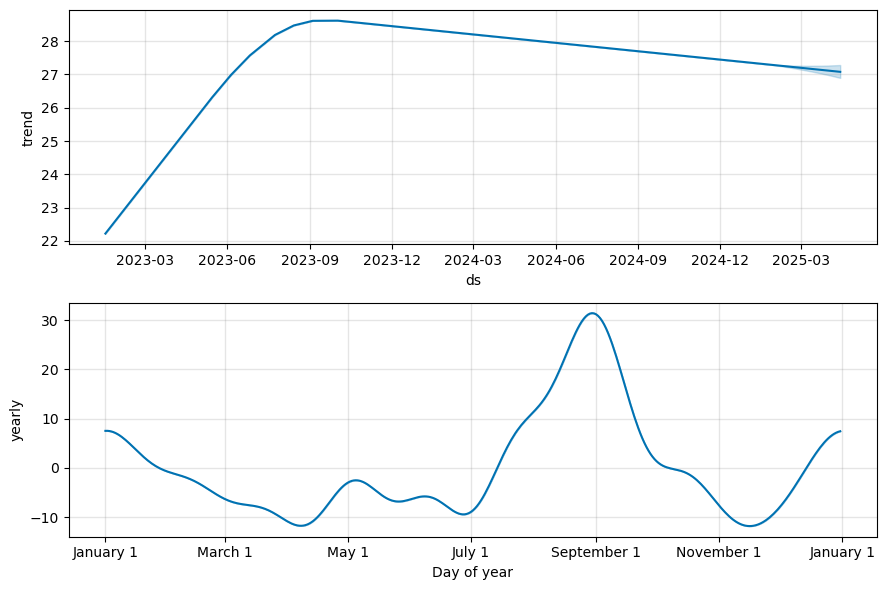

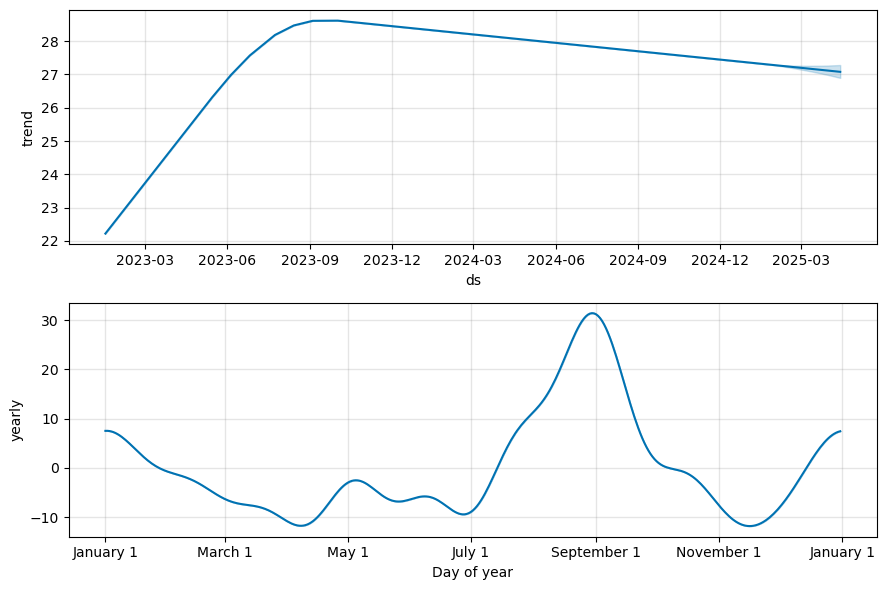

In [14]:
model.plot_components(forecast_baseline_data)

•	adjust hyperparaméters with cross validation methode

In [15]:
import itertools
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# 1. Grille de recherche d'hyperparamètres
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0],
}

# Générer toutes les combinaisons
all_params = [
    dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())
]
wape_results = []

# 2. Boucle de Grid Search
for params in all_params:
    m = Prophet(
        holidays=holidays_df,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        holidays_prior_scale=params['holidays_prior_scale'],
        
    )

    # Intégration du régresseur commercial (ex: opportunités décalées)

    m.fit(df_data)

    # Cross-validation
    df_cv = cross_validation(
        m, initial='365 days', period='60 days', horizon='84 days'
    )

    # Calcul du WAPE
    wape = (
        abs(df_cv['y'] - df_cv['yhat']).sum() / df_cv['y'].sum()
    ) * 100
    wape_results.append((wape, params))

# 3. Meilleure combinaison
best_wape, best_params = sorted(wape_results, key=lambda x: x[0])[0]
print(f"Meilleur WAPE : {best_wape:.2f}% avec les paramètres : {best_params}")

01:15:01 - cmdstanpy - INFO - Chain [1] start processing
01:15:01 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/7 [00:00<?, ?it/s]

01:15:02 - cmdstanpy - INFO - Chain [1] start processing
01:15:02 - cmdstanpy - INFO - Chain [1] done processing
01:15:02 - cmdstanpy - INFO - Chain [1] start processing
01:15:03 - cmdstanpy - INFO - Chain [1] done processing
01:15:03 - cmdstanpy - INFO - Chain [1] start processing
01:15:04 - cmdstanpy - INFO - Chain [1] done processing
01:15:04 - cmdstanpy - INFO - Chain [1] start processing
01:15:05 - cmdstanpy - INFO - Chain [1] done processing
01:15:05 - cmdstanpy - INFO - Chain [1] start processing
01:15:06 - cmdstanpy - INFO - Chain [1] done processing
01:15:07 - cmdstanpy - INFO - Chain [1] start processing
01:15:07 - cmdstanpy - INFO - Chain [1] done processing
01:15:08 - cmdstanpy - INFO - Chain [1] start processing
01:15:08 - cmdstanpy - INFO - Chain [1] done processing
01:15:08 - cmdstanpy - INFO - Chain [1] start processing
01:15:08 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing i

  0%|          | 0/7 [00:00<?, ?it/s]

01:15:08 - cmdstanpy - INFO - Chain [1] start processing
01:15:09 - cmdstanpy - INFO - Chain [1] done processing
01:15:10 - cmdstanpy - INFO - Chain [1] start processing
01:15:11 - cmdstanpy - INFO - Chain [1] done processing
01:15:12 - cmdstanpy - INFO - Chain [1] start processing
01:15:13 - cmdstanpy - INFO - Chain [1] done processing
01:15:13 - cmdstanpy - INFO - Chain [1] start processing
01:15:14 - cmdstanpy - INFO - Chain [1] done processing
01:15:14 - cmdstanpy - INFO - Chain [1] start processing
01:15:15 - cmdstanpy - INFO - Chain [1] done processing
01:15:15 - cmdstanpy - INFO - Chain [1] start processing
01:15:16 - cmdstanpy - INFO - Chain [1] done processing
01:15:16 - cmdstanpy - INFO - Chain [1] start processing
01:15:16 - cmdstanpy - INFO - Chain [1] done processing
01:15:17 - cmdstanpy - INFO - Chain [1] start processing
01:15:17 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing i

...

  0%|          | 0/7 [00:00<?, ?it/s]

01:20:45 - cmdstanpy - INFO - Chain [1] start processing
01:20:46 - cmdstanpy - INFO - Chain [1] done processing
01:20:46 - cmdstanpy - INFO - Chain [1] start processing
01:20:48 - cmdstanpy - INFO - Chain [1] done processing
01:20:48 - cmdstanpy - INFO - Chain [1] start processing
01:20:50 - cmdstanpy - INFO - Chain [1] done processing
01:20:50 - cmdstanpy - INFO - Chain [1] start processing
01:20:52 - cmdstanpy - INFO - Chain [1] done processing
01:20:53 - cmdstanpy - INFO - Chain [1] start processing
01:20:55 - cmdstanpy - INFO - Chain [1] done processing
01:20:55 - cmdstanpy - INFO - Chain [1] start processing
01:20:57 - cmdstanpy - INFO - Chain [1] done processing
01:20:57 - cmdstanpy - INFO - Chain [1] start processing
01:20:57 - cmdstanpy - INFO - Chain [1] done processing
01:20:58 - cmdstanpy - INFO - Chain [1] start processing
01:20:58 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing i

  0%|          | 0/7 [00:00<?, ?it/s]

01:20:58 - cmdstanpy - INFO - Chain [1] start processing
01:20:59 - cmdstanpy - INFO - Chain [1] done processing
01:20:59 - cmdstanpy - INFO - Chain [1] start processing
01:21:00 - cmdstanpy - INFO - Chain [1] done processing
01:21:01 - cmdstanpy - INFO - Chain [1] start processing
01:21:03 - cmdstanpy - INFO - Chain [1] done processing
01:21:03 - cmdstanpy - INFO - Chain [1] start processing
01:21:05 - cmdstanpy - INFO - Chain [1] done processing
01:21:06 - cmdstanpy - INFO - Chain [1] start processing
01:21:08 - cmdstanpy - INFO - Chain [1] done processing
01:21:08 - cmdstanpy - INFO - Chain [1] start processing
01:21:10 - cmdstanpy - INFO - Chain [1] done processing
01:21:10 - cmdstanpy - INFO - Chain [1] start processing
01:21:10 - cmdstanpy - INFO - Chain [1] done processing


Meilleur WAPE : 50.86% avec les paramètres : {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'holidays_prior_scale': 1.0}


In [ ]:
•	adjust hyperparameter without cross validation

In [18]:
import itertools
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


def grid_search_prophet_train_test(
    df, holidays_df, periods=12, param_grid=None
):
    if param_grid is None:
        param_grid = {
            'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
            'seasonality_prior_scale': [0.1, 1.0, 10.0],
            'holidays_prior_scale': [0.1, 1.0, 10.0],
        }

    # 1. Découpage Train / Test
    train_df = df.iloc[:-periods].copy()
    test_df = df.iloc[-periods:].copy()
    y_true = test_df['y'].values

    # 2. Génération de toutes les combinaisons possibles
    all_params = [
        dict(zip(param_grid.keys(), v))
        for v in itertools.product(*param_grid.values())
    ]
    results = []

    # 3. Boucle d'optimisation
    for params in all_params:
        model = Prophet(
            holidays=holidays_df,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            weekly_seasonality=False,
            daily_seasonality=False,
            
        )

        model.fit(train_df)

        # Prévision
        future = model.make_future_dataframe(periods=periods, freq='W-MON')
        forecast = model.predict(future)

        # Extraction de la période de test
        y_pred = forecast['yhat'].iloc[-periods:].values

        # Calcul des métriques
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

        results.append({
            'changepoint_prior_scale': params['changepoint_prior_scale'],
            'seasonality_prior_scale': params['seasonality_prior_scale'],
            'holidays_prior_scale': params['holidays_prior_scale'],
            'MAE': round(mae, 2),
            'MAPE': round(mape, 2),
            'WAPE': round(wape, 2),
        })

    # Classement des résultats par WAPE croissant
    df_results = pd.DataFrame(results).sort_values(by='WAPE').reset_index(drop=True)
    best_params = df_results.iloc[0].to_dict()

    return best_params, df_results


# --- EXÉCUTION SUR TOUS TES DOMAINES ---

domaines_dict = {
    'Data/Cloud': df_data,
    'Cybersécurité': df_cyber,
    'DevOps': df_devops,
    'Dev Fullstack': df_dev,
    'Agile': df_agile,
}

recap_meilleurs_parametres = []

for name, df_dom in domaines_dict.items():
    print(f"⏳ Recherche des meilleurs hyperparamètres pour : {name}...")
    best, df_res = grid_search_prophet_train_test(
        df_dom, holidays_df, periods=12
    )

    recap_meilleurs_parametres.append({
        'Domaine': name,
        'Best CPS': best['changepoint_prior_scale'],
        'Best SPS': best['seasonality_prior_scale'],
        'Best HPS': best['holidays_prior_scale'],
        'MAE': best['MAE'],
        'MAPE (%)': f"{best['MAPE']}%",
        'WAPE (%)': f"{best['WAPE']}%",
    })

# Affichage du tableau récapitulatif
df_recap = pd.DataFrame(recap_meilleurs_parametres)
print("\n=== MEILLEURES COMBINAISONS PAR DOMAINE ===")
display(df_recap)

01:24:50 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing


⏳ Recherche des meilleurs hyperparamètres pour : Data/Cloud...


01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:51 - cmdstanpy - INFO - Chain [1] done processing
01:24:51 - cmdstanpy - INFO - Chain [1] start processing
01:24:52 - cmdstanpy - INFO - Chain [1] done processing
01:24:52 - cmdstanpy - INFO - Chain [1] start processing
01:24:52 - cmdstanpy - INFO - Chain [1] done processing
01:24:52 - cmdstanpy - INFO - Chain [1] start processing
01:24:52 - cmdstanpy - INFO - Chain [1] done processing
01:24:52 - cmdstanpy - INFO - Chain [1] start processing
01:24:53 - cmdstanpy - INFO - Chain [1] done processing
01:24:53 - cmdstanpy - INFO - Chain [1] start processing
01:24:53 - cmdstanpy - INFO - Chain [1] done processing
01:24:53 - cmdstanpy - INFO - Chain [1] start processing
01:24:53 - cmdstanpy - INFO - Chain [1] done processing
01:24:53 - cmdstanpy - INFO - Chain [1] start processing
01:24:54 - cmdstanpy - INFO - Chain [1]

⏳ Recherche des meilleurs hyperparamètres pour : Cybersécurité...


01:25:07 - cmdstanpy - INFO - Chain [1] done processing
01:25:08 - cmdstanpy - INFO - Chain [1] start processing
01:25:08 - cmdstanpy - INFO - Chain [1] done processing
01:25:08 - cmdstanpy - INFO - Chain [1] start processing
01:25:08 - cmdstanpy - INFO - Chain [1] done processing
01:25:09 - cmdstanpy - INFO - Chain [1] start processing
01:25:09 - cmdstanpy - INFO - Chain [1] done processing
01:25:09 - cmdstanpy - INFO - Chain [1] start processing
01:25:09 - cmdstanpy - INFO - Chain [1] done processing
01:25:09 - cmdstanpy - INFO - Chain [1] start processing
01:25:09 - cmdstanpy - INFO - Chain [1] done processing
01:25:10 - cmdstanpy - INFO - Chain [1] start processing
01:25:10 - cmdstanpy - INFO - Chain [1] done processing
01:25:11 - cmdstanpy - INFO - Chain [1] start processing
01:25:11 - cmdstanpy - INFO - Chain [1] done processing
01:25:12 - cmdstanpy - INFO - Chain [1] start processing
01:25:12 - cmdstanpy - INFO - Chain [1] done processing
01:25:12 - cmdstanpy - INFO - Chain [1] 

...

01:25:44 - cmdstanpy - INFO - Chain [1] start processing
01:25:44 - cmdstanpy - INFO - Chain [1] done processing
01:25:45 - cmdstanpy - INFO - Chain [1] start processing
01:25:45 - cmdstanpy - INFO - Chain [1] done processing
01:25:45 - cmdstanpy - INFO - Chain [1] start processing
01:25:45 - cmdstanpy - INFO - Chain [1] done processing
01:25:45 - cmdstanpy - INFO - Chain [1] start processing
01:25:46 - cmdstanpy - INFO - Chain [1] done processing
01:25:46 - cmdstanpy - INFO - Chain [1] start processing
01:25:46 - cmdstanpy - INFO - Chain [1] done processing
01:25:46 - cmdstanpy - INFO - Chain [1] start processing
01:25:46 - cmdstanpy - INFO - Chain [1] done processing
01:25:47 - cmdstanpy - INFO - Chain [1] start processing
01:25:47 - cmdstanpy - INFO - Chain [1] done processing
01:25:47 - cmdstanpy - INFO - Chain [1] start processing
01:25:47 - cmdstanpy - INFO - Chain [1] done processing
01:25:48 - cmdstanpy - INFO - Chain [1] start processing
01:25:48 - cmdstanpy - INFO - Chain [1]

⏳ Recherche des meilleurs hyperparamètres pour : Agile...


01:26:02 - cmdstanpy - INFO - Chain [1] start processing
01:26:02 - cmdstanpy - INFO - Chain [1] done processing
01:26:02 - cmdstanpy - INFO - Chain [1] start processing
01:26:03 - cmdstanpy - INFO - Chain [1] done processing
01:26:03 - cmdstanpy - INFO - Chain [1] start processing
01:26:03 - cmdstanpy - INFO - Chain [1] done processing
01:26:04 - cmdstanpy - INFO - Chain [1] start processing
01:26:04 - cmdstanpy - INFO - Chain [1] done processing
01:26:04 - cmdstanpy - INFO - Chain [1] start processing
01:26:04 - cmdstanpy - INFO - Chain [1] done processing
01:26:05 - cmdstanpy - INFO - Chain [1] start processing
01:26:05 - cmdstanpy - INFO - Chain [1] done processing
01:26:05 - cmdstanpy - INFO - Chain [1] start processing
01:26:05 - cmdstanpy - INFO - Chain [1] done processing
01:26:06 - cmdstanpy - INFO - Chain [1] start processing
01:26:06 - cmdstanpy - INFO - Chain [1] done processing
01:26:06 - cmdstanpy - INFO - Chain [1] start processing
01:26:06 - cmdstanpy - INFO - Chain [1]


=== MEILLEURES COMBINAISONS PAR DOMAINE ===


,Domaine,Best CPS,Best SPS,Best HPS,MAE,MAPE (%),WAPE (%)
0,Data/Cloud,0.01,1.0,1.0,6.40,35.81%,27.04%
1,Cybersécurité,0.05,10.0,1.0,2.23,37.18%,22.87%
2,DevOps,0.05,0.1,1.0,3.46,30.44%,28.08%
3,Dev Fullstack,0.30,10.0,10.0,3.04,34.96%,31.41%
4,Agile,0.30,10.0,0.1,1.96,17.4%,16.14%


analyse des volume d'opportunité

In [19]:

df_v2 = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v2.xlsx")

print("\nStatistiques du volume par domaine :")
print(
    df_v2.groupby("domaine")["volume_opportunites"]
    .agg(["min", "mean", "max"])
    .round(2)
)

print("\nVolume moyen par mois :")
print(
    df_v2.assign(mois=df["ds"].dt.month)
    .groupby("mois")["volume_opportunites"]
    .mean()
    .round(2)
)


Statistiques du volume par domaine :
                  min   mean  max
domaine                          
Agile & Delivery    0   3.85    8
Cybersécurité       1   4.24    9
Data/Cloud          2  18.79   35
Dev Fullstack       1   5.79   12
DevOps / Infra      1   8.79   16

Volume moyen par mois :
mois
1      6.97
2     10.60
3     10.46
4     10.56
5     10.42
6      9.48
7      4.18
8      1.90
9      9.33
10    12.04
11     9.32
12     2.82
Name: volume_opportunites, dtype: float64


•	script Prophet with regressor & holidays & seasonality & hyperparameters

In [37]:
import itertools
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Chargement du dataset principal
df_all = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v2.xlsx")

# Si tes opportunités sont dans un autre fichier, fusionne-les ici :
# df_opp = pd.read_excel('opportunites.xlsx')
# df_all = pd.merge(df_all, df_opp, on=['ds', 'domaine'], how='left')

# 2. Création de la variable décalée (Lag 4 semaines) par domaine
LAG_WEEKS = 4
df_all['opp_lag4'] = df_all.groupby('domaine')['volume_opportunites'].shift(LAG_WEEKS)


# 3. Fonction de Grid Search intégrant le régresseur externe
def grid_search_prophet_regressor(df_dom, holidays_df, periods=12, param_grid=None):
    if param_grid is None:
        param_grid = {
            'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
            'seasonality_prior_scale': [0.1, 1.0, 10.0],
            'holidays_prior_scale': [0.1, 1.0, 10.0],
        }

    # Retrait des premières lignes devenues NaN à cause du shift
    df_clean = df_dom.dropna(subset=['opp_lag4']).copy()

    train_df = df_clean.iloc[:-periods].copy()
    test_df = df_clean.iloc[-periods:].copy()
    y_true = test_df['y'].values

    all_params = [
        dict(zip(param_grid.keys(), v))
        for v in itertools.product(*param_grid.values())
    ]
    results = []

    for params in all_params:
        model = Prophet(
            holidays=holidays_df,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            weekly_seasonality=False,
            daily_seasonality=False,
        )

        # Ajout du régresseur externe
        model.add_regressor('opp_lag4')
        model.fit(train_df)

        # Création du dataframe futur
        future = model.make_future_dataframe(periods=periods, freq='W-MON')

        # Association des valeurs réelles passées + propagation pour le futur
        future = future.merge(df_clean[['ds', 'opp_lag4']], on='ds', how='left')
        future['opp_lag4'] = future['opp_lag4'].ffill()

        forecast = model.predict(future)
        y_pred = forecast['yhat'].iloc[-periods:].values

        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

        results.append({
            'changepoint_prior_scale': params['changepoint_prior_scale'],
            'seasonality_prior_scale': params['seasonality_prior_scale'],
            'holidays_prior_scale': params['holidays_prior_scale'],
            'MAE': round(mae, 2),
            'MAPE': round(mape, 2),
            'WAPE': round(wape, 2),
        })

    df_results = pd.DataFrame(results).sort_values(by='WAPE').reset_index(drop=True)
    best_params = df_results.iloc[0].to_dict()

    return best_params, df_results


# 4. Exécution dynamique sur tous les domaines du fichier Excel
domaines = df_all['domaine'].unique()
recap_meilleurs_parametres = []

for dom in domaines:
    print(f"⏳ Optimisation pour le domaine : {dom}...")
    df_dom = df_all[df_all['domaine'] == dom].sort_values('ds')

    best, df_res = grid_search_prophet_regressor(df_dom, holidays_df, periods=12)

    recap_meilleurs_parametres.append({
        'Domaine': dom,
        'Best CPS': best['changepoint_prior_scale'],
        'Best SPS': best['seasonality_prior_scale'],
        'Best HPS': best['holidays_prior_scale'],
        'MAE': best['MAE'],
        'MAPE (%)': f"{best['MAPE']}%",
        'WAPE (%)': f"{best['WAPE']}%",
    })

# Tableau récapitulatif final
df_recap = pd.DataFrame(recap_meilleurs_parametres)
print("\n=== MEILLEURES COMBINAISONS AVEC RÉGRESSEUR EXTERNE ===")
display(df_recap)

07:59:45 - cmdstanpy - INFO - Chain [1] start processing


⏳ Optimisation pour le domaine : Agile & Delivery...


07:59:46 - cmdstanpy - INFO - Chain [1] done processing
07:59:46 - cmdstanpy - INFO - Chain [1] start processing
07:59:46 - cmdstanpy - INFO - Chain [1] done processing
07:59:46 - cmdstanpy - INFO - Chain [1] start processing
07:59:46 - cmdstanpy - INFO - Chain [1] done processing
07:59:47 - cmdstanpy - INFO - Chain [1] start processing
07:59:47 - cmdstanpy - INFO - Chain [1] done processing
07:59:47 - cmdstanpy - INFO - Chain [1] start processing
07:59:47 - cmdstanpy - INFO - Chain [1] done processing
07:59:47 - cmdstanpy - INFO - Chain [1] start processing
07:59:47 - cmdstanpy - INFO - Chain [1] done processing
07:59:48 - cmdstanpy - INFO - Chain [1] start processing
07:59:48 - cmdstanpy - INFO - Chain [1] done processing
07:59:48 - cmdstanpy - INFO - Chain [1] start processing
07:59:48 - cmdstanpy - INFO - Chain [1] done processing
07:59:48 - cmdstanpy - INFO - Chain [1] start processing
07:59:48 - cmdstanpy - INFO - Chain [1] done processing
07:59:49 - cmdstanpy - INFO - Chain [1] 

⏳ Optimisation pour le domaine : Cybersécurité...


08:00:02 - cmdstanpy - INFO - Chain [1] done processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] done processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] done processing
08:00:04 - cmdstanpy - INFO - Chain [1] start processing
08:00:04 - cmdstanpy - INFO - Chain [1] done processing
08:00:04 - cmdstanpy - INFO - Chain [1] start processing
08:00:04 - cmdstanpy - INFO - Chain [1] done processing
08:00:05 - cmdstanpy - INFO - Chain [1] start processing
08:00:05 - cmdstanpy - INFO - Chain [1] done processing
08:00:05 - cmdstanpy - INFO - Chain [1] start processing
08:00:05 - cmdstanpy - INFO - Chain [1] done processing
08:00:06 - cmdstanpy - INFO - Chain [1] start processing
08:00:06 - cmdstanpy - INFO - Chain [1] done processing
08:00:06 - cmdstanpy - INFO - Chain [1] start processing
08:00:06 - cmdstanpy - INFO - Chain [1] done processing
08:00:06 - cmdstanpy - INFO - Chain [1] 

...

08:00:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:00:42 - cmdstanpy - INFO - Chain [1] start processing
08:00:43 - cmdstanpy - INFO - Chain [1] done processing
08:00:43 - cmdstanpy - INFO - Chain [1] start processing
08:00:43 - cmdstanpy - INFO - Chain [1] done processing
08:00:43 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:00:43 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] done processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] done processing
08:00:44 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] done processing
08:00:45 - c

⏳ Optimisation pour le domaine : DevOps / Infra...


08:01:07 - cmdstanpy - INFO - Chain [1] done processing
08:01:07 - cmdstanpy - INFO - Chain [1] start processing
08:01:07 - cmdstanpy - INFO - Chain [1] done processing
08:01:08 - cmdstanpy - INFO - Chain [1] start processing
08:01:08 - cmdstanpy - INFO - Chain [1] done processing
08:01:08 - cmdstanpy - INFO - Chain [1] start processing
08:01:08 - cmdstanpy - INFO - Chain [1] done processing
08:01:09 - cmdstanpy - INFO - Chain [1] start processing
08:01:09 - cmdstanpy - INFO - Chain [1] done processing
08:01:09 - cmdstanpy - INFO - Chain [1] start processing
08:01:09 - cmdstanpy - INFO - Chain [1] done processing
08:01:10 - cmdstanpy - INFO - Chain [1] start processing
08:01:10 - cmdstanpy - INFO - Chain [1] done processing
08:01:10 - cmdstanpy - INFO - Chain [1] start processing
08:01:10 - cmdstanpy - INFO - Chain [1] done processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] done processing
08:01:11 - cmdstanpy - INFO - Chain [1] 


=== MEILLEURES COMBINAISONS AVEC RÉGRESSEUR EXTERNE ===


,Domaine,Best CPS,Best SPS,Best HPS,MAE,MAPE (%),WAPE (%)
0,Agile & Delivery,0.05,10.0,10.0,1.10,8.93%,9.06%
1,Cybersécurité,0.05,10.0,10.0,1.08,12.55%,11.03%
2,Data/Cloud,0.30,10.0,10.0,2.98,15.75%,12.61%
3,Dev Fullstack,0.05,0.1,1.0,0.95,11.72%,9.85%
4,DevOps / Infra,0.30,10.0,0.1,1.87,15.58%,15.14%


L'utilisation du volume d'opportunités comme régresseur externe crée une dépendance temporelle en cascade. Pour 
prédire le nombre de consultants en Bench et le TACE à un horizon futur (par exemple à M+2 ou M+3), le modèle 
Prophet exige impérativement de connaître les valeurs futures du régresseur sur cette même période. 
En l'absence de valeurs réelles constatées pour le pipeline commercial futur à long terme, nous devons recourir à une 
prédiction préalable du volume d'opportunités. 

ajout du model cascade pour volume d'opportunité sans hyperparameters

In [34]:
from prophet import Prophet
import pandas as pd
for dom in domaines:
    print(f"⏳ Optimisation pour le domaine : {dom}...")
    df_dom = df_all[df_all['domaine'] == dom].sort_values('ds')
# --- ÉTAPE 1 : Préchercher le volume d'opportunités futur ---
    df_opp = df_dom[['ds', 'volume_opportunites']].rename(columns={'volume_opportunites': 'y'})

    model_opp = Prophet(holidays=holidays_df, weekly_seasonality=False)
    train_df_opp = df_opp.iloc[:-12].copy()
    test_df_opp = df_opp.iloc[-12:].copy()
    y_true_opp = test_df_opp['y'].values
    model_opp.fit(train_df_opp)

# Prédiction des 12 prochaines semaines d'opportunités
    future_opp = model_opp.make_future_dataframe(periods=12, freq='W-MON')
    forecast_opp = model_opp.predict(future_opp)
    y_pred_opp = forecast_opp['yhat'].iloc[-12:].values

    mae = mean_absolute_error(y_true_opp, y_pred_opp)
    print(mae)
    mape = mean_absolute_percentage_error(y_true_opp, y_pred_opp) * 100
    print(mape)

# Reconstruction de la série temporelle globale d'opportunités (Passé + Futur)
#df_opp_complete = forecast_opp[['ds', 'yhat']].rename(columns={'yhat': 'volume_opportunites'})

06:53:23 - cmdstanpy - INFO - Chain [1] start processing


⏳ Optimisation pour le domaine : Agile & Delivery...


06:53:23 - cmdstanpy - INFO - Chain [1] done processing
06:53:24 - cmdstanpy - INFO - Chain [1] start processing


1.185566053780902
26.68711176014596
⏳ Optimisation pour le domaine : Cybersécurité...


06:53:24 - cmdstanpy - INFO - Chain [1] done processing
06:53:24 - cmdstanpy - INFO - Chain [1] start processing
06:53:24 - cmdstanpy - INFO - Chain [1] done processing


1.0904147432730813
20.664309843553706
⏳ Optimisation pour le domaine : Data/Cloud...


06:53:25 - cmdstanpy - INFO - Chain [1] start processing
06:53:25 - cmdstanpy - INFO - Chain [1] done processing


4.045809940802083
21.059842583834833
⏳ Optimisation pour le domaine : Dev Fullstack...


06:53:25 - cmdstanpy - INFO - Chain [1] start processing
06:53:25 - cmdstanpy - INFO - Chain [1] done processing


1.8817947475731083
25.58192162064121
⏳ Optimisation pour le domaine : DevOps / Infra...
2.1226704791613358
23.008558150778562


script pour predire valeur opportunité des 12 prochaine semaines (regresseur) avec hyperparameters

In [36]:
import itertools
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Grille d'hyperparamètres pour le modèle des opportunités
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0],
}

all_params = [
    dict(zip(param_grid.keys(), v))
    for v in itertools.product(*param_grid.values())
]

recap_optimisation_opp = []
dict_opp_complet = {}  # Pour stocker les séries complètes (Passé + Futur) par domaine

for dom in domaines:
    print(f"\n⏳ Optimisation de la prédiction des opportunités pour : {dom}...")
    df_dom = df_all[df_all['domaine'] == dom].sort_values('ds')

    # --- ÉTAPE 1 : Préparation des données d'opportunités ---
    df_opp = df_dom[['ds', 'volume_opportunites']].rename(
        columns={'volume_opportunites': 'y'}
    )

    train_df_opp = df_opp.iloc[:-12].copy()
    test_df_opp = df_opp.iloc[-12:].copy()
    y_true_opp = test_df_opp['y'].values

    best_wape = float('inf')
    best_params_opp = None

    # --- ÉTAPE 2 : Grid Search sur le volume d'opportunités ---
    for params in all_params:
        model_opp = Prophet(
            holidays=holidays_df,
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            weekly_seasonality=False,
            daily_seasonality=False,
        )
        model_opp.fit(train_df_opp)

        future_opp = model_opp.make_future_dataframe(periods=12, freq='W-MON')
        forecast_opp = model_opp.predict(future_opp)
        y_pred_opp = forecast_opp['yhat'].iloc[-12:].values

        # Evaluation par WAPE
        wape = (
            np.sum(np.abs(y_true_opp - y_pred_opp)) / np.sum(y_true_opp)
        ) * 100

        if wape < best_wape:
            best_wape = wape
            best_params_opp = params

    # Evaluation finale de la meilleure combinaison sur le Test Set
    model_best_eval = Prophet(
        holidays=holidays_df,
        changepoint_prior_scale=best_params_opp['changepoint_prior_scale'],
        seasonality_prior_scale=best_params_opp['seasonality_prior_scale'],
        holidays_prior_scale=best_params_opp['holidays_prior_scale'],
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    model_best_eval.fit(train_df_opp)
    forecast_eval = model_best_eval.predict(future_opp)
    y_pred_best = forecast_eval['yhat'].iloc[-12:].values

    mae_best = mean_absolute_error(y_true_opp, y_pred_best)
    mape_best = mean_absolute_percentage_error(y_true_opp, y_pred_best) * 100

    print(f"  ✅ Meilleurs paramètres Opp : {best_params_opp}")
    print(
        f"  📊 MAE: {mae_best:.2f} | MAPE: {mape_best:.2f}% | WAPE:"
        f" {best_wape:.2f}%"
    )

    recap_optimisation_opp.append({
        'Domaine': dom,
        'Best CPS (Opp)': best_params_opp['changepoint_prior_scale'],
        'Best SPS (Opp)': best_params_opp['seasonality_prior_scale'],
        'Best HPS (Opp)': best_params_opp['holidays_prior_scale'],
        'MAE Opp': round(mae_best, 2),
        'WAPE Opp (%)': f"{round(best_wape, 2)}%",
    })

    # --- ÉTAPE 3 : Fit complet sur TOUTES les données réelles et projection dans le futur ---
    model_opp_final = Prophet(
        holidays=holidays_df,
        changepoint_prior_scale=best_params_opp['changepoint_prior_scale'],
        seasonality_prior_scale=best_params_opp['seasonality_prior_scale'],
        holidays_prior_scale=best_params_opp['holidays_prior_scale'],
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    model_opp_final.fit(df_opp)

    future_opp_final = model_opp_final.make_future_dataframe(
        periods=12, freq='W-MON'
    )
    forecast_opp_final = model_opp_final.predict(future_opp_final)

    # DataFrame complet d'opportunités (Passé + 12 semaines futures prédites)
    df_opp_complete = forecast_opp_final[['ds', 'yhat']].rename(
        columns={'yhat': 'volume_opportunites'}
    )
    dict_opp_complet[dom] = df_opp_complete

# Affichage du bilan d'optimisation du régresseur
df_recap_opp = pd.DataFrame(recap_optimisation_opp)
print("\n=== BILAN OPTIMISATION DES OPPORTUNITÉS ===")
display(df_recap_opp)

07:45:30 - cmdstanpy - INFO - Chain [1] start processing



⏳ Optimisation de la prédiction des opportunités pour : Agile & Delivery...


07:45:30 - cmdstanpy - INFO - Chain [1] done processing
07:45:30 - cmdstanpy - INFO - Chain [1] start processing
07:45:30 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:33 - cmdstanpy - INFO - Chain [1] 

  ✅ Meilleurs paramètres Opp : {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 0.1, 'holidays_prior_scale': 1.0}
  📊 MAE: 1.16 | MAPE: 26.02% | WAPE: 27.76%


07:45:48 - cmdstanpy - INFO - Chain [1] done processing
07:45:49 - cmdstanpy - INFO - Chain [1] start processing


...

07:46:46 - cmdstanpy - INFO - Chain [1] done processing
07:46:47 - cmdstanpy - INFO - Chain [1] start processing



⏳ Optimisation de la prédiction des opportunités pour : DevOps / Infra...


07:46:47 - cmdstanpy - INFO - Chain [1] done processing
07:46:47 - cmdstanpy - INFO - Chain [1] start processing
07:46:47 - cmdstanpy - INFO - Chain [1] done processing
07:46:48 - cmdstanpy - INFO - Chain [1] start processing
07:46:48 - cmdstanpy - INFO - Chain [1] done processing
07:46:48 - cmdstanpy - INFO - Chain [1] start processing
07:46:48 - cmdstanpy - INFO - Chain [1] done processing
07:46:49 - cmdstanpy - INFO - Chain [1] start processing
07:46:49 - cmdstanpy - INFO - Chain [1] done processing
07:46:49 - cmdstanpy - INFO - Chain [1] start processing
07:46:49 - cmdstanpy - INFO - Chain [1] done processing
07:46:50 - cmdstanpy - INFO - Chain [1] start processing
07:46:50 - cmdstanpy - INFO - Chain [1] done processing
07:46:50 - cmdstanpy - INFO - Chain [1] start processing
07:46:51 - cmdstanpy - INFO - Chain [1] done processing
07:46:51 - cmdstanpy - INFO - Chain [1] start processing
07:46:51 - cmdstanpy - INFO - Chain [1] done processing
07:46:52 - cmdstanpy - INFO - Chain [1] 

  ✅ Meilleurs paramètres Opp : {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 0.1, 'holidays_prior_scale': 1.0}
  📊 MAE: 2.07 | MAPE: 22.08% | WAPE: 19.55%

=== BILAN OPTIMISATION DES OPPORTUNITÉS ===


,Domaine,Best CPS (Opp),Best SPS (Opp),Best HPS (Opp),MAE Opp,WAPE Opp (%)
0,Agile & Delivery,0.30,0.1,1.0,1.16,27.76%
1,Cybersécurité,0.01,0.1,0.1,1.08,22.68%
2,Data/Cloud,0.05,10.0,1.0,4.04,17.84%
3,Dev Fullstack,0.01,0.1,1.0,0.90,12.96%
4,DevOps / Infra,0.30,0.1,1.0,2.07,19.55%


•	resultat de prevision des volumes opportunité predict pour chaque domaine

In [45]:
print(df_opp_complete.iloc[-12:])
print(dict_opp_complet)

            ds  volume_opportunites
118 2025-04-21            11.214465
119 2025-04-28            11.734191
120 2025-05-05            11.607661
121 2025-05-12            10.799183
122 2025-05-19            10.201150
123 2025-05-26            10.721052
124 2025-06-02            12.081310
125 2025-06-09            12.720934
126 2025-06-16            11.163163
127 2025-06-23             7.588774
128 2025-06-30             3.920351
129 2025-07-07             2.138688
{'Agile & Delivery':             ds  volume_opportunites
0   2023-01-16             4.101935
1   2023-01-23             4.321907
2   2023-01-30             4.189961
3   2023-02-06             3.929646
4   2023-02-13             3.825402
..         ...                  ...
124 2025-06-02             6.415783
125 2025-06-09             5.544404
126 2025-06-16             4.712631
127 2025-06-23             4.086069
128 2025-06-30             3.498307

[129 rows x 2 columns], 'Cybersécurité':             ds  volume_opportunites
0

•	complete pipe line de prediction des 3 prochaines mois 

In [20]:
import pandas as pd
import numpy as np
from prophet import Prophet
import logging

# Désactiver les logs verbeux de cmdstanpy dans la console
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
# ==========================================
# 1. DICTIONNAIRES DES HYPERPARAMÈTRES OPTIMAUX
# ==========================================

# Extraits du bilan des opportunités
BEST_PARAMS_OPP = {
    'Agile & Delivery': {'cps': 0.30, 'sps': 0.1, 'hps': 1.0},
    'Cybersécurité': {'cps': 0.01, 'sps': 0.1, 'hps': 0.1},
    'Data/Cloud': {'cps': 0.05, 'sps': 10.0, 'hps': 1.0},
    'Dev Fullstack': {'cps': 0.01, 'sps': 0.1, 'hps': 1.0},
    'DevOps / Infra': {'cps': 0.30, 'sps': 0.1, 'hps': 1.0},
}

# Extraits du modèle principal avec régresseur
BEST_PARAMS_BENCH = {
    'Agile & Delivery': {'cps': 0.05, 'sps': 10.0, 'hps': 10.0},
    'Cybersécurité': {'cps': 0.05, 'sps': 10.0, 'hps': 10.0},
    'Data/Cloud': {'cps': 0.30, 'sps': 10.0, 'hps': 10.0},
    'Dev Fullstack': {'cps': 0.05, 'sps': 0.1, 'hps': 1.0},
    'DevOps / Infra': {'cps': 0.30, 'sps': 10.0, 'hps': 0.1},
}


# ==========================================
# 2. FONCTIONS DE PRÉDICTION EN CASCADE
# ==========================================

def predict_opportunities(df_dom, dom_name, holidays_df, periods=12):
    """
    Fonction 1 : Prédit le volume d'opportunités sur les 3 prochains mois.
    """
    try:
        df_opp = df_dom[['ds', 'volume_opportunites']].rename(columns={'volume_opportunites': 'y'})
        params = BEST_PARAMS_OPP.get(dom_name, {'cps': 0.05, 'sps': 1.0, 'hps': 1.0}) # Valeurs par défaut si domaine introuvable

        model_opp = Prophet(
            holidays=holidays_df,
            changepoint_prior_scale=params['cps'],
            seasonality_prior_scale=params['sps'],
            holidays_prior_scale=params['hps'],
            weekly_seasonality=False,
            daily_seasonality=False
        )
        model_opp.fit(df_opp)

        future_opp = model_opp.make_future_dataframe(periods=periods, freq='W-MON')
        forecast_opp = model_opp.predict(future_opp)
        
        # On retourne la série temporelle complète (historique + futur)
        df_opp_complete = forecast_opp[['ds', 'yhat']].rename(columns={'yhat': 'volume_opportunites'})
        
        # Arrondir à l'entier (on ne peut pas avoir une demi-opportunité)
        df_opp_complete['volume_opportunites'] = df_opp_complete['volume_opportunites'].round().astype(int)
        # Éviter les prédictions négatives impossibles
        df_opp_complete['volume_opportunites'] = df_opp_complete['volume_opportunites'].clip(lower=0)
        
        return df_opp_complete

    except Exception as e:
        logging.error(f"Erreur lors de la prédiction des opportunités pour {dom_name}: {e}")
        return None


def predict_bench_tace(df_dom, df_opp_complete, dom_name, holidays_df, periods=12):
    """
    Fonction 2 : Utilise les opportunités avec un décalage de 4 semaines pour prédire le bench et le TACE.
    """
    try:
        # 1. Application du lag sur les opportunités (Passé + Futur)
        df_opp_complete = df_opp_complete.copy()
        df_opp_complete['opp_lag4'] = df_opp_complete['volume_opportunites'].shift(4)

        # 2. Préparation du dataset d'entraînement
        df_train = pd.merge(df_dom[['ds', 'y']], df_opp_complete[['ds', 'opp_lag4']], on='ds', how='right')
        df_train_clean = df_train.dropna(subset=['y', 'opp_lag4']).copy() # Historique pur pour le .fit()

        # 3. Entraînement du modèle
        params = BEST_PARAMS_BENCH.get(dom_name, {'cps': 0.05, 'sps': 1.0, 'hps': 1.0})
        model_bench = Prophet(
            holidays=holidays_df,
            changepoint_prior_scale=params['cps'],
            seasonality_prior_scale=params['sps'],
            holidays_prior_scale=params['hps'],
            weekly_seasonality=False,
            daily_seasonality=False
        )
        model_bench.add_regressor('opp_lag4')
        model_bench.fit(df_train_clean)

        # 4. Prédiction sur l'ensemble de la timeline (incluant les périodes futures)
        future_bench = df_train[['ds', 'opp_lag4']].copy()
        
        # Sécurité : remplir les potentiels NaN futurs du régresseur par la dernière valeur
        future_bench['opp_lag4'] = future_bench['opp_lag4'].bfill().ffill() 
        
        forecast_bench = model_bench.predict(future_bench)

        # 5. Calcul des métriques finales (Bench et TACE)
        df_final = forecast_bench[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        df_final.rename(columns={'yhat': 'bench_pred', 'yhat_lower': 'bench_min', 'yhat_upper': 'bench_max'}, inplace=True)
        
        # Nettoyage des valeurs aberrantes
        df_final['bench_pred'] = df_final['bench_pred'].clip(lower=0).round()
        df_final['bench_min'] = df_final['bench_min'].clip(lower=0).round()
        
        # Propagation de l'effectif total pour calculer le TACE
        last_effectif = df_dom['effectif_total'].iloc[-1]
        df_final['effectif_total'] = last_effectif
        
        df_final['tace_pred'] = ((df_final['effectif_total'] - df_final['bench_pred']) / df_final['effectif_total']) * 100
        df_final['domaine'] = dom_name

        return df_final

    except Exception as e:
        logging.error(f"Erreur lors de la prédiction du bench pour {dom_name}: {e}")
        return None

# ==========================================
# 3. EXÉCUTION DU PIPELINE (Wrapper Principal)
# ==========================================

def run_forecasting_pipeline(df_all, holidays_df, periods=12):
    """
    Orchestre les deux fonctions pour tous les domaines et consolide les résultats.
    Idéal pour être appelé via un bouton dans Streamlit.
    """
    domaines = df_all['domaine'].unique()
    all_predictions = []

    for dom in domaines:
        print(f"Traitement en cours pour : {dom}...")
        df_dom = df_all[df_all['domaine'] == dom].sort_values('ds')
        
        # Étape 1 : Prédire les opportunités commerciales
        df_opp_complete = predict_opportunities(df_dom, dom, holidays_df, periods)
        
        if df_opp_complete is not None:
            # Étape 2 : Prédire le bench et le TACE
            df_final = predict_bench_tace(df_dom, df_opp_complete, dom, holidays_df, periods)
            
            if df_final is not None:
                # Ajout des vraies données historiques pour comparaison facile dans le dashboard
                df_final = pd.merge(df_final, df_dom[['ds', 'y', 'tace']], on='ds', how='left')
                all_predictions.append(df_final)
                
    if all_predictions:
        return pd.concat(all_predictions, ignore_index=True)
    else:
        return pd.DataFrame() # Retourne un dataframe vide si tout échoue en sécurité

•	le chatbot sur notre resultat de prevision

In [19]:
import pandas as pd
import google.generativeai as genai


# 1. Chargement des données et Holidays (identique à ton code)
df_all = pd.read_excel(r"C:\Users\omounabbih\Documents\project_prophet_bench\rapport_par_semaine_domaine_v3.xlsx")

holidays_df = pd.DataFrame({
    'holiday': ['fete_du_travail', 'victoire_1945', 'ascension', 'fete_nationale', 'vacances_ete', 'assomption', 'noel'] * 3,
    'ds': pd.to_datetime([
        '2023-05-01', '2023-05-08', '2023-05-18', '2023-07-14', '2023-08-01', '2023-08-15', '2023-12-25',
        '2024-05-01', '2024-05-08', '2024-05-09', '2024-07-14', '2024-08-01', '2024-08-15', '2024-12-25',
        '2025-05-01', '2025-05-08', '2025-05-29', '2025-07-14', '2025-08-01', '2025-08-15', '2025-12-25'
    ]),
    'lower_window': [0]*21,
    'upper_window': [0, 0, 3, 2, 14, 0, 6, 0, 0, 3, 0, 14, 1, 6, 1, 1, 3, 2, 14, 2, 7]
})

# 2. Exécution des prédictions
print("⏳ Calcul des prévisions en cours...")
df_results = run_forecasting_pipeline(df_all, holidays_df, periods=64)

# 3. Configuration de l'API Gemini
GEMINI_API_KEY = "Your API Key Here" # Remplace par ta clé
genai.configure(api_key=GEMINI_API_KEY)
model = genai.GenerativeModel('gemini-3.5-flash')
# 4. Aggregation des données pour le Prompt System
summary_data = df_results.groupby('domaine').agg({
    'bench_pred': ['mean', 'max'],
    'tace_pred': ['mean', 'min']
}).round(1).to_string()

system_instruction = f"""
Tu es un expert RH et Business Analyst spécialisé en ESN.
Analyse les données de prévision TACE (%) et Bench (nombre de consultants) ci-dessous :

{summary_data}

Instructions :
- Sois concis, clair et direct.
- Utilise des puces si nécessaire.
- Propose des recommandations concrètes d'optimisation de staffing.
"""

# 5. Simulation de questions / réponses dans la console
questions_test = [
    "Fais-moi un résumé global des prévisions pour les prochains mois.",
    "Quel est le domaine le plus critique qui risque d'avoir le plus de bench ?",
    "Quelle stratégie RH recommanderais-tu pour le pôle Dev Fullstack ?"
]

for q in questions_test:
    print(f"\n❓ USER: {q}")
    full_prompt = f"{system_instruction}\n\nQuestion de l'utilisateur : {q}"
    
    response = model.generate_content(full_prompt)
    print(f"🤖 GEMINI:\n{response.text}")
    print("-" * 50)

04:48:42 - cmdstanpy - INFO - Chain [1] start processing
04:48:42 - cmdstanpy - INFO - Chain [1] done processing


⏳ Calcul des prévisions en cours...
Traitement en cours pour : Agile & Delivery...


04:48:42 - cmdstanpy - INFO - Chain [1] start processing
04:48:42 - cmdstanpy - INFO - Chain [1] done processing
04:48:43 - cmdstanpy - INFO - Chain [1] start processing
04:48:43 - cmdstanpy - INFO - Chain [1] done processing


Traitement en cours pour : Cybersécurité...


04:48:43 - cmdstanpy - INFO - Chain [1] start processing
04:48:43 - cmdstanpy - INFO - Chain [1] done processing
04:48:43 - cmdstanpy - INFO - Chain [1] start processing
04:48:43 - cmdstanpy - INFO - Chain [1] done processing


...

Traitement en cours pour : Dev Fullstack...


04:48:44 - cmdstanpy - INFO - Chain [1] start processing
04:48:44 - cmdstanpy - INFO - Chain [1] done processing
04:48:44 - cmdstanpy - INFO - Chain [1] start processing
04:48:44 - cmdstanpy - INFO - Chain [1] done processing


Traitement en cours pour : DevOps / Infra...


04:48:45 - cmdstanpy - INFO - Chain [1] start processing
04:48:45 - cmdstanpy - INFO - Chain [1] done processing



❓ USER: Fais-moi un résumé global des prévisions pour les prochains mois.
🤖 GEMINI:
Voici l'analyse synthétique des prévisions d'activité (TACE) et de gestion des effectifs (Bench) pour les prochains mois.

### **1. Constats Clés : Une activité solide mais une forte volatilité**

*   **Le moteur de croissance : Data/Cloud**
    *   Meilleur TACE moyen (**84,8%**) et meilleur TACE min (**66,1%**).
    *   **Point de vigilance majeur :** Le volume de bench est critique. Avec une moyenne de **29 consultants** et un pic prévu à **65**, c'est le pôle qui présente le plus grand risque financier en cas de retard de signature.
*   **La zone de risque : Agile & Delivery**
    *   TACE moyen le plus faible (**80,9%**) et un risque de sous-activité marqué (TACE min à **57,8%**).
    *   Le bench peut monter jusqu'à **27 consultants**.
*   **Stabilité relative : Dev Fullstack**
    *   La practice la plus saine : TACE moyen correct (**81,9%**), risque de baisse maîtrisé (TACE min le plus haut à *